In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    RocCurveDisplay
)
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Heiti SC', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示异常


%matplotlib inline

In [2]:


# 加载数据，移除头部、签名、引用等噪音
newsgroups = fetch_20newsgroups(
    subset='all',
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

X = newsgroups.data
y = newsgroups.target
class_names = newsgroups.target_names

print(f"样本总数: {len(X)}")
print(f"类别数: {len(class_names)}")
print(f"类别名称: {class_names}")

样本总数: 18846
类别数: 20
类别名称: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


In [3]:
# TF-IDF 向量化
vectorizer = TfidfVectorizer(
    max_features=5000,   # 保留最高频的 5000 个词
    stop_words='english',
    ngram_range=(1, 2)
)

X_tfidf = vectorizer.fit_transform(X)

# 划分训练集 / 测试集  8:2
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print(f"训练集形状: {X_train.shape}")
print(f"测试集形状: {X_test.shape}")

训练集形状: (15076, 5000)
测试集形状: (3770, 5000)


In [4]:
# 定义模型字典
models = {
    "MultinomialNB": MultinomialNB(),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "LinearSVC": LinearSVC(random_state=42)
}

# 存储每个模型的预测结果
results = {}

for name, model in models.items():
    print(f"正在训练 {name} ...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "accuracy": acc
    }
    print(f"{name} 准确率: {acc:.4f}\n")

正在训练 MultinomialNB ...
MultinomialNB 准确率: 0.6939

正在训练 LogisticRegression ...
LogisticRegression 准确率: 0.7034

正在训练 LinearSVC ...
LinearSVC 准确率: 0.6886



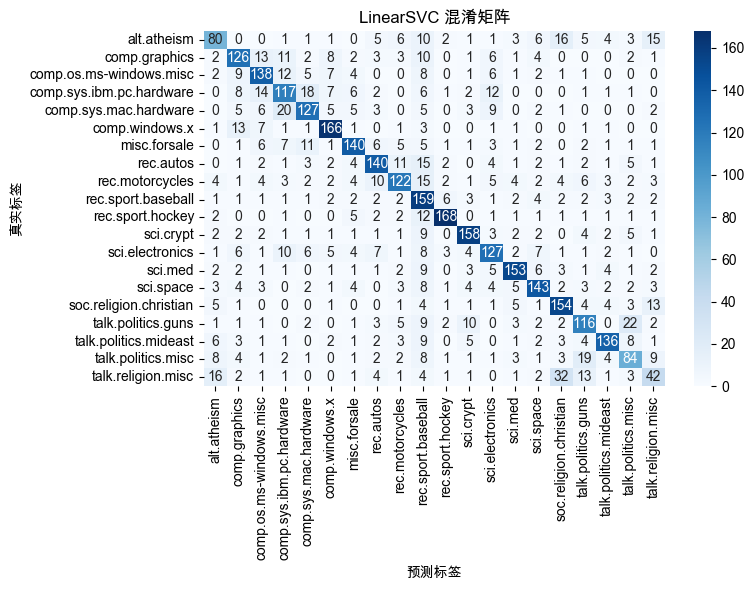

LinearSVC 分类报告：
                          precision    recall  f1-score   support

             alt.atheism       0.59      0.50      0.54       160
           comp.graphics       0.66      0.65      0.65       195
 comp.os.ms-windows.misc       0.68      0.70      0.69       197
comp.sys.ibm.pc.hardware       0.61      0.60      0.60       196
   comp.sys.mac.hardware       0.69      0.66      0.68       193
          comp.windows.x       0.78      0.84      0.81       198
            misc.forsale       0.75      0.72      0.73       195
               rec.autos       0.73      0.71      0.72       198
         rec.motorcycles       0.71      0.61      0.66       199
      rec.sport.baseball       0.50      0.80      0.62       199
        rec.sport.hockey       0.88      0.84      0.86       200
               sci.crypt       0.79      0.80      0.79       198
         sci.electronics       0.67      0.64      0.66       197
                 sci.med       0.81      0.77      0.79    

In [12]:
def plot_confusion_matrix(y_true, y_pred, class_names, title="混淆矩阵"):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel('预测标签')
    plt.ylabel('真实标签')
    plt.title(title)
    plt.tight_layout()
    plt.show()

# 以 LinearSVC 为例
plot_confusion_matrix(
    y_test,
    results["LinearSVC"]["y_pred"],
    class_names,
    title="LinearSVC 混淆矩阵"
)

# 打印详细分类报告
print("LinearSVC 分类报告：")
print(classification_report(y_test, results["LinearSVC"]["y_pred"], target_names=class_names))

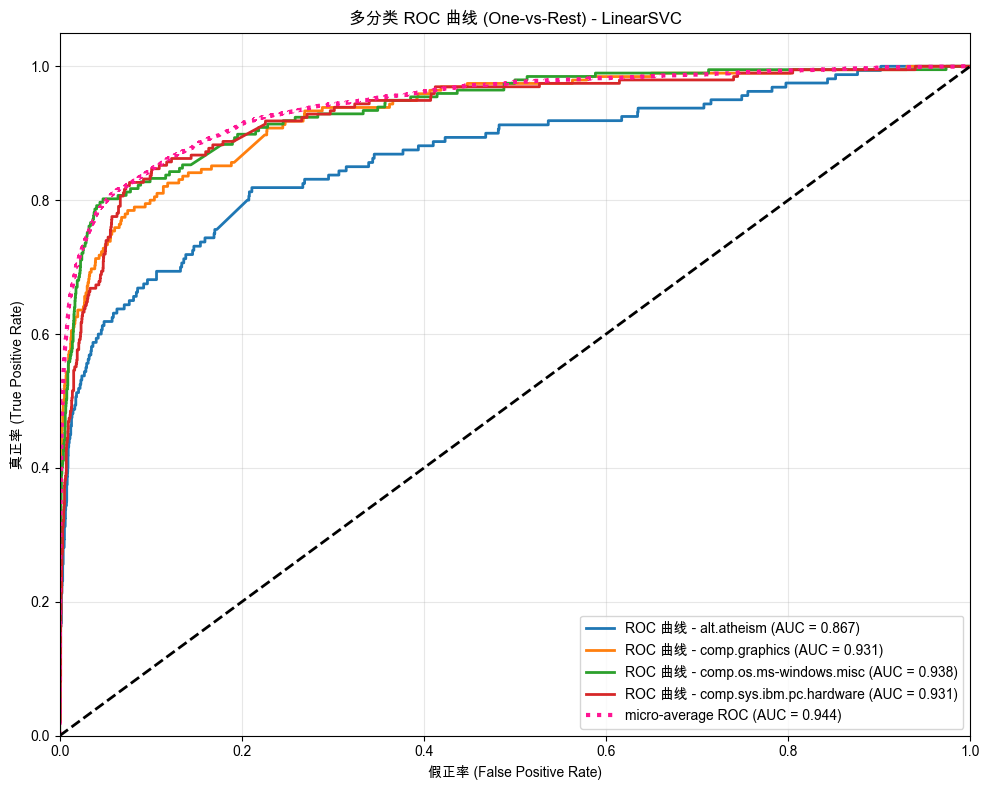

In [13]:
# 将标签二值化，用于多分类 ROC
y_test_bin = label_binarize(y_test, classes=range(len(class_names)))
n_classes = y_test_bin.shape[1]

# 选择能输出概率/决策分数的模型（LinearSVC 用 decision_function）
model_for_roc = OneVsRestClassifier(LinearSVC(random_state=42))
model_for_roc.fit(X_train, y_train)

# 获取决策分数
y_score = model_for_roc.decision_function(X_test)

# 计算每个类别的 ROC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 计算 micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# 绘制 ROC 曲线
plt.figure(figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr[i], tpr[i],
        color=color,
        lw=2,
        label=f'ROC 曲线 - {class_names[i]} (AUC = {roc_auc[i]:.3f})'
    )

plt.plot(
    fpr["micro"], tpr["micro"],
    label=f'micro-average ROC (AUC = {roc_auc["micro"]:.3f})',
    color='deeppink',
    linestyle=':',
    linewidth=3
)

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('假正率 (False Positive Rate)')
plt.ylabel('真正率 (True Positive Rate)')
plt.title('多分类 ROC 曲线 (One-vs-Rest) - LinearSVC')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

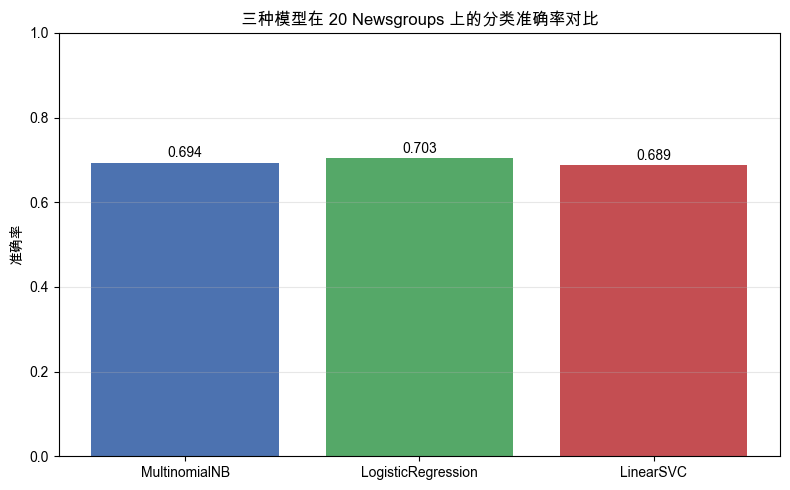

In [14]:
model_names = list(results.keys())
accuracies = [results[m]["accuracy"] for m in model_names]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=['#4c72b0', '#55a868', '#c44e52'])
plt.ylim(0.0, 1.0)
plt.ylabel('准确率')
plt.title('三种模型在 20 Newsgroups 上的分类准确率对比')

# 在柱子上标注数值
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.,
        height + 0.005,
        f'{height:.3f}',
        ha='center', va='bottom'
    )

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()